In [1]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier, SGDRegressor
import numpy as np

# Under the hood

## Plan 

1. What happens behind `.fit()`?
2. Gradient Descent
3. Other solvers?
4. Loss Functions

# 1. What happens behind `.fit()`?

In [2]:
import pandas as pd
data = pd.DataFrame({'weight':[0.7,2.4,2.8],'height':[1.5,1.8,3.2]})

Consider the following data:

In [3]:
data

,weight,height
0,0.7,1.5
1,2.4,1.8
2,2.8,3.2


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/simple_dataset.png" width="300"/>

Train a Linear Regression model:

In [4]:
from sklearn.linear_model import LinearRegression

# Instanciate Linear model
model = LinearRegression()

# Train Linear Model
model.fit(data[['weight']], data['height'])

LinearRegression()

The model is now trained and its optimal parameters can be accessed.

In [5]:
print('beta_0 intercept =', model.intercept_)
print('beta_1 slope =', model.coef_[0])

beta_0 intercept = 0.9434316353887398
beta_1 slope = 0.6219839142091154


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ML4-best-fit-line.png" width="300"/>

### What happens during `.fit()` ?

Any model can be expressed as $y = h(X, \color{blue}{\beta}) + error $ 

- $h(X,\beta) = \color{blue}{\beta_0} + \color{blue}{\beta_1} X_1 $ in our example 

- $h$ is called our **hypothesis** function

- $h(X,\beta)$ is called our **prediction** ($\hat{y}$)  

👉 `.fit()` finds parameters $\color{blue}{\beta_0}$ and $\color{blue}{\beta_1}$ which **minimize** the $error(X,y,\color{blue}{\beta})$

❓ Which **norm** is used to measure error in $\mathbb{R} $ numbers?

**The Loss Function L**

`.fit()` minimizes $L(error)$. 

$L_{OLS} = \|error \|^2 = \|y -  \color{blue}{\beta_0} - \color{blue}{\beta_1} X_1\|^2$

We write: $\color{blue}{\beta} = \text{arg}\,\min\limits_{\beta}\ L(\color{blue}{\beta}, X, y, h)$

**There exist numerous "solvers" to minimize L($\beta$)** beyond Gradient Descent
- Exact mathematical resolution (matrix inversion, often too complex, hence only used in "simple" ML models, like [SVD in Linear Regression](https://sthalles.github.io/svd-for-regression/))
- Iterative approaches

```python
# In Sklearn, these methods are called "solvers"
LogisticRegression(solver='newton-cg')
```

✏️ **Let's try to think about our own solver** 

Imagine that we already know the value of the ideal slope ($\beta_1 = 0.64$), and need to find the optimal intercept ($\beta_0$):

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_3.png" width="600"/>

- Randomly initialize an intercept, say at 0.
- Compute the Loss at that intercept value
- Here, the Loss is the **Sum of Squared Residuals**


Then, change the intercept and repeat the process until we find the minimum Loss.  
Look at the Loss Function: it has a convex shape.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_4.png" width="600"/>

⚠️ Problems:
- We could miss the exact minimum if our steps are too large
- We don't know the best $\beta_1$ to start with

👉 We need to tweak both $\beta_0$ and $\beta_1$ simulatneously at each iteration

So let's discover together the most basic but very powerful iterative method: **`the Gradient Descent`**

# 2.  Gradient Descent

## 2.1 1-D descent step-by-step

- Uses **the slope (gradient) of the Loss Function** as an indicator
- As the slope approaches zero, the Loss approaches its minimum


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_15.png" width="600"/>

The slope is equal to the **partial derivative** of the Loss Function with respect to the parameter of interest:

$$
\frac{\partial\ Loss\ Function}{\partial\ parameter}
$$

✏️ Let's go back to our example. 

❶ First
- Initializing a random parameter value. Let's say $\beta_0 = 0$
- Calculating the derivative of the Loss Function at that point $\frac{\partial SSR}{\partial \beta_0}(0)$

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_8.png" width="300"/>

❷ Then move by a **step** in the opposite direction of the derivative

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_10.png" width="600"/>

- the step-size is **proportional** to derivative value

- with a chosen **Learning Rate** = $\eta$ (eta) 
$$\\ \beta_0^{\color{red}{(1)}} = 0 - \eta \frac{\partial L}{\partial \beta_0}(0)$$

We just did one $\color{red}{\text{Epoch}}$ !

👉 Repeat the process:

The updated intercept value is plugged back into the derivative of the Loss function, and we repeat the process.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_11.png" width="600"/>

As the **Loss** approaches its minimum, the derivative gets smaller, and so do the steps.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_12.png" width="600"/>

This makes Gradient Descent computationally efficient. It does  a few calculations far away from the minimum, and more calculations as it approaches the minimum of the Loss Function.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_5.png" width="600"/>

#### When does it stop?

The Gradient Descent algorithm  can have different **stopping criterions** :

- **`Minimum Step Size`** (e.g. 0.001). When the step size is smaller, the Gradient Descent has converged, and the corresponding intercept is the optimal value.
- **`Maximum Number of steps`** (e.g. 1000)

$$\beta_0^{\color {red}{(k+1)}} = \beta_0^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_0}(\beta_0^{\color{red}{(k)}})$$

**1-D descent summary**


1. Randomly initialize the parameter value $$ \color{blue}{\beta_0^{\color{red}{(0)}}}$$
2. Compute the derivative of the loss function at that point
3. Update the parameter value with the step size $\eta$
4. Go back to step 2 with the updated value of the parameter 

Repeat steps 2 to 4 until the Gradient Descent hits the stopping criteria of your choice (either Minimum Step Size or Maximum Number of Steps).

### Analytical solution

Can we compute is $\frac{\partial SRR}{\partial \color{blue}{\beta_0}}$ for our example?

$$
SSR(\color{blue}{\beta}\color{black}{)} = \sum_{i=1}^n (y_i - \hat{y}_i )^2 = \sum_{i=1}^n (y_i - (\color{blue}{\beta}_0+ \beta_{\color{green}{1}} X_{\color{green}{1}}^{(i)}\color{black}{)} )^2
$$

We can compute its partial derivative with respect to $\color{blue}{\beta_0}$

$$
\frac{\partial SRR}{\partial \color{blue}{\beta_0}}= \sum_{i=1}^n - 2 (y_i - (\color{blue}{\beta_0} + \beta_{\color{green}{1}} X_{\color{green}{1}}^{(i)}) )= \sum_{i=1}^n -2(y_i - \hat{y}_i ) 
$$

💡 $f(g)' = g' * f'(g)$

### ✏️ We can now code our own Gradient Descent for our example

In [6]:
import numpy as np

In [7]:
data

,weight,height
0,0.7,1.5
1,2.4,1.8
2,2.8,3.2


In [8]:
X = data['weight']
y = data['height']
b1 = 0.64 # b1 fixed at 0.64
eta = 0.1 # Learning rate fixed

# Hypothesis function h
def h(x,b0):
    return b0 + b1*x

# Initialize intercept at 0 for this example
b0_epoch0 = 0

# L(b0_epoch_0)
np.sum((y-h(X,b0_epoch0)) ** 2)

3.1588640000000012

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_3.png" width="300"/>

In [9]:
# Step 1: Compute the derivative of the Loss function at b0_epoch_0
derivative = np.sum(-2*(y-h(X,b0_epoch0)))
derivative

-5.448

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_8.png" width="150"/>

In [10]:
# Step 2: Update the intercept
b0_epoch1 = b0_epoch0 - (eta * derivative)

b0_epoch1

0.5448000000000001

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_10.png" width="300"/>

#### Repeat

That was one **Epoch**! 

Let's do a second one!

In [11]:
# Step1: Compute the new derivative at b0_epoch1
derivative = np.sum(-2*(y-h(X,b0_epoch1)))

# Step2: Update the previsouly updated intercept
b0_epoch2 = b0_epoch1 - eta * derivative
b0_epoch2

0.7627200000000002

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_11.png" width="350"/>

Keep going until it converges to the minimum!

## 2.2 2D descent : How to co-optimize $\beta_0$ and $\beta_1$  ?

The Loss Function would be represented in a  3-dimensional space and look something like this. 
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/3d_loss_function.jpg" width="400"/>

Or like this in more complex problems  

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_descent_3d.jpeg'>  

☝️ This is called the **Energy Landscape** of the loss function  

☝️ Notice the projected **2D contour plot** below

We re-iterate the same procedure for both parameters **simultaneously**.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_13.png" width="300"/>

What about a **3D** problem? $\beta = (\beta_0, \beta_1, \beta_2)$

Below is the 3D plot of your **observations** 👇
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/3D%20plane.png'>

The associated **energy landscape** of the loss function is in **4D** 🤯

### Vectorial formulation (_N dimensions_)

1. Start with random values of $\beta_0$ and $\beta_1$ (epoch 0)

2. At each **epoch** $k$, update both $(\beta_0^{\color {red}{(k+1)}}, \beta_1^{\color {red}{(k+1)}}$) in the direction of the "downward-pointing gradient"

$$
\beta_0^{\color {red}{(k+1)}} = \beta_0^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_0}(\beta^{\color{red}{(k)}})
$$


$$
\beta_1^{\color {red}{(k+1)}} = \beta_1^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_1}(\beta^{\color {red}{(k)}})
$$

- with a learning rate $\eta$ (eta)

This vector of partial derivatives is called the **gradient** vector $\nabla $ 

$${\displaystyle \nabla L(\beta)={\begin{bmatrix}{\frac {\partial L}{\partial \beta_{0}}}(\beta)\\\vdots \\{\frac {\partial L}{\partial \beta_{p}}}(\beta)\end{bmatrix}}.}$$

💡 Hence the name *Gradient Descent*

$$\text{Gradient Descent - vector formula}$$
$$\beta^{\color {red}{(k+1)}} = \beta^{\color {red}{(k)}} - \eta \ \nabla L(\beta^{\color{red}{(k)}})$$

$\color{blue}{Blue}$ $\color{blue}{arrows}$ indicate the direction and strength of the gradient of this energy landscape.  
It is null at the loss minimum.
<img src='https://upload.wikimedia.org/wikipedia/commons/d/d2/3d-gradient-cos.svg'>

### Effect of learning rate $\eta$?
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/learning_rate_comparison.png'>

📚 [Distill](https://distill.pub/2017/momentum/)

**Small learning rate**
- shorter path to mimimum
- requires more epochs
- may get stuck at local minima

**Large learning rate**
- requires less epochs
- may never converge!

💡 **The Gradient Descent algorithms always converges faster when features are scaled ! [Why?](https://datascience.stackexchange.com/questions/55656/why-does-feature-scaling-improve-the-convergence-speed-for-gradient-descent)**

### Analytical gradient for OLS regression (Linear Regression + SSR Loss)

We can also compute the following partial derivatives:

$$
\frac{\partial SSR}{\partial \color{blue}{\beta_0}}(\color{blue}{\beta})= \sum_{i=1}^n -2(y_i - \hat{y}_i ) 
$$


$$
\frac{\partial SSR}{\partial \color{blue}{\beta_1}}(\color{blue}{\beta})= \sum_{i=1}^n -2 X_1^{(i)} (y_i - \hat{y}_i )
$$

and more generally speaking:

$$\nabla SSR(\color{blue}{\beta}) = -2 X^T (y - \hat{y})$$

$$\nabla SSR(\color{blue}{\beta}) = -2 X^T (y - X\color{blue}\beta)$$

☝️ Because the formula for the gradient of the loss is so easy to compute, Gradient Descent is very efficient for OLS Regressions

💪 You will implement this iterative Gradient Descent in today's challenges.

### (optional) Can we get a geometric intuition about the best $\beta$ in OLS ? 📐

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient-formula-half.png'>

<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/8/87/OLS_geometric_interpretation.svg/1920px-OLS_geometric_interpretation.svg.png' width=500>

$\hat{y} = X \beta$ must lie somewhere in the [**column space**](https://www.omnicalculator.com/math/column-space
) of $X$  
(the hyperplane defined by the span of all possible linear combination of features $X_i$) 



<br>
❓ What is the position (defined by choice of $\beta$) that minimizes the OLS loss $(y - \hat{y})^2$ ❓

💡 Pythagoras tells us that the shortest path is
>  the **orthogonal projection** of $y_{true}$ into the hyperplane (col X)

# 3. Other Solvers?

Let's recall the definition of the gradient $\color{blue}{\text{ (for OLS)} }$

$${\displaystyle \nabla L(\beta)=
{\begin{bmatrix}{\frac {\partial L}{\partial \beta_{0}}}(\beta)\\\vdots \\{\frac {\partial L}{\partial \beta_{p}}}(\beta)\end{bmatrix}} \color{blue}{=
{\begin{bmatrix}{\sum_{i=0}^n ... }\\\vdots \\{\sum_{i=0}^n ...}\end{bmatrix}} = -2 X^T (y - \hat{y})} 
}$$

👎 Gradient Descent is **computationally expensive** on big datasets:

- At **each epoch**, evaluating $\nabla L$ requires using all $n$ observations, for each of those $p$ features


❓ Couldn't we use **less than all $n$ observations** to compute an approximate "loss"?

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/gradient_desc_4_bis.png" width="600"/>

### Minibatch Gradient Descent

> At each iteration, compute an **"approximate" Loss** and take one step against its gradient

- Choose minibatch size (e.g. 16)

- Loop over your $n$ observations, minibatch-per-minibatch
    1. For each minibatch $X_{mini}$ (e.g. the first 16 observations)
    2. Compute the gradient of the mini-batch $\nabla L_{mini}$
    3. Use this gradient to update $\beta^{\color {red}{(k+1)}} = \beta^{\color {red}{(k)}} - \eta \ \nabla L_{mini}(\beta^{\color{red}{(k)}})$
    4. Move to next $X_{mini}$ (e.g. the 16-32 obs)

- Once all $n$ observations have been viewed, repeat another **epoch**

### Stochastic Gradient Descent (SGD)


`SDG` $\Leftrightarrow$ `Mini-Batch of size 1`

- Loop one-by-one over all $n$ observations
    - Select a **single, randomly selected data point** 
    - Compute the Loss/gradient for this single point
    - Update $\beta$
- Once all $n$ observations have been viewed, repeat another epoch

💻 Let's code it for our OLS

In [12]:
b0 = 0
eta = 0.1
n_epoch = 5 # We have to choose when to stop

for epoch in range(n_epoch):
    # Loop randomly over all 3 data points in our example
    for i in np.random.permutation(3):

        # Select a minibatch (of size 1)
        X_mini = X[i]

        # Compute gradient of the loss at b_0
        y_pred = h(X_mini,b0)
        y_true = y[i]
        derivative = -2*(y_true-y_pred)

        # Update b_0
        b0 = b0 - eta * derivative
        print(f'b0 epoch {epoch}:', b0)

b0 epoch 0: 0.2816000000000001
b0 epoch 0: 0.27808000000000005
b0 epoch 0: 0.432864
b0 epoch 1: 0.5566912
b0 epoch 1: 0.4981529600000001
b0 epoch 1: 0.6801223680000001
b0 epoch 2: 0.7544978944000001
b0 epoch 2: 0.8851983155200003
b0 epoch 2: 0.7609586524160002
b0 epoch 3: 0.8903669219328003
b0 epoch 3: 0.7650935375462403
b0 epoch 3: 0.8224748300369923
b0 epoch 4: 0.9395798640295939
b0 epoch 4: 0.8044638912236751
b0 epoch 4: 0.8539711129789401


Due to working on a single point rather than the dataset average, the SGD is less stable.

- The **Loss _fluctuates_** from epoch to epoch more and does not necessarily decrease
- As a result, the **steps** taken are **less direct** towards the minimum

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/SGD.png" width="600"/>
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/loss_bgd_sgd.png" width="600"/>


<font color=green>Pros</font>
- SGD is faster for very large datasets
- Jumps out of local minima!
- Greatly reduces RAM load (see Deep Learning)

<font color=red>Cons</font>
- Needs more epochs
- Never exactly converges (careful when to stop?)
- Maybe slower for small $n$ datasets with many features $p$


👉 **Use when**
- Your dataset has 6 digits or more # of observations
- You want to get un-stuck from a local minimum
- By default?

#### Sklearn [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) and [`SGDClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)

- `SGDRegressor` is a Linear Model (Linear Regression) that uses the Stochastic Gradient Descent as a `solver` to minimize its Loss Function (MSE)


- `SGDClassifier` is a Linear Model (Logistic "Regression") that use the Stochastic Gradient Descent as a `solver` to minimize its Loss Function (Log Loss)

NB: We'll talk about these Loss Functions in detail in section 4.

In [13]:
from sklearn.linear_model import SGDRegressor, LinearRegression

lin_reg = LinearRegression() # OLS solved by matrix inversion (SVD method)

lin_reg_sgd = SGDRegressor(loss='squared_error') # OLS solved by SGD

In [14]:
from sklearn.datasets import make_regression

# Create a "fake problem" to solve
X, y = make_regression(n_samples=10000, n_features=1000)

In [15]:
%%time
lin_reg.fit(X,y)

CPU times: user 7.65 s, sys: 1.7 s, total: 9.35 s
Wall time: 723 ms


LinearRegression()

In [16]:
%%time
lin_reg_sgd.fit(X,y)

CPU times: user 306 ms, sys: 1.93 s, total: 2.24 s
Wall time: 169 ms


SGDRegressor()

✅ Gradient Descent performs better than matrix inversion when feature number $p$ is large  
✅ Stochastic GD scales even better when number of observation $n$ large

### Other solvers?

#### 1) Enhanced gradient descents

<img src=https://miro.medium.com/max/800/1*zVi4ayX9u0MQQwa90CnxVg.gif width=500>

- <font color=cyan>Gradient</font>  
- <font color=magenta>Momentum</font> (adds inertia)

<img src='https://miro.medium.com/max/1400/1*47skUygd3tWf3yB9A10QHg.gif' width=500>

- <font color=cyan>Gradient</font>
- <font color=magenta>Momentum</font> (adds inertia)
- <font color=grey>AdaGrad</font> (adaptative $\eta$ per feature - prioritize weakly updated params)
- <font color=green>RMSProp</font> (adds decay - only recent gradient matters)
- <font color=blue>Adam</font> (all combined)

📚[Credits](https://towardsdatascience.com/a-visual-explanation-of-gradient-descent-methods-momentum-adagrad-rmsprop-adam-f898b102325c)

#### 2) Second-order partial derivatives methods (Hessian matrix)

At each iteration one approximates $h(x)$ using a **quadratic** function instead of a "slope"

- Newton’s Method
- L-BFGS (approx. Hessian)

<font color=green>Pros:</font> Converges with far fewer epochs

<font color=red>Cons:</font> Computationally expensive

👉 Used for "easy ML" problems. Default sklearn "LogisticRegression" solver


# 4. Loss Functions L

- Squared Loss is not the only loss function that you can minimize to fit a regression
```python
SGDRegressor(loss='squared_loss')
SGDRegressor(loss='huber')
```

- Same "model" class on sklearn can be instantiated with various attributes for `loss`
```python
SGDClassifier(loss='log')
SGDClassifier(loss='hinge')
```

- Classification and Regression have different loss functions by nature


### 3.1 Loss ≠ Performance Metrics

Performance metrics are computed **after** the model is fitted

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/crossval.png" width="400"/>

**Regression perf metrics** (MSE, RMSE, RMSLE, MAE, $R^2$...)

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/MSE.png" width="300"/>

**Classification Metrics** (Accuracy, Precision, Recall, F1...)

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/confusion_matrix.jpg" width="300"/>

**Loss** is used to **fit** the model

- Sometimes loss and perf metrics may be the same (e.g. MSE)

- But loss needs to be **(sub)differentiable** (ie. smooth)

👉 "Accuracy" for instance can never be used as a loss metric


## 3.1 Regression Loss Functions

### L1 Loss (MAE) vs L2 Loss (MSE) 

<table>
        <td>
            $$ L_1 = MAE = \frac{1}{n}\sum_{i=1}^n | \hat{y}_i - y_i| $$
        </td>
        <td>
            &emsp;&emsp;
        </td>
        <td>
            &emsp;&emsp;
        </td>
        <td>
            $$ L_2 = MSE = \frac{1}{n}\sum_{i=1}^n (\hat{y}_i - y_i)^2$$
        </td>
</table>

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/mse_vs_mae_learning.png" width="700"/>

- MSE very sensitive to outliers vs. MAE which is less strict
- MAE requires learning rate $\eta$ which decreases at every epoch


### Huber Loss (mix of L1 and L2 losses, also called _Smooth Absolute Loss_)

- MAE which becomes MSE when error is small, typically adjustable by hyperparameter [`epsilon`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor:~:text=The%20verbosity%20level.-,epsilon,-float%2C%20default%3D0.1)
- Adjustable for outliers
- Slope can be used as an indicator of reaching minima


\begin{split}L_{\delta}=\left\{\begin{matrix}
\frac{1}{2}(y - \hat{y})^{2} & if \left | (y - \hat{y})  \right | < \delta\\
\delta (| (y - \hat{y}) | - \frac1 2 \delta) & otherwise
\end{matrix}\right.\end{split}

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/huber_loss.png" width="500"/>

## 3.2 Classification Losses

### Logistic classifiers


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/decision-science/logistic-regression2.png' width=600>

- We want to predict a binary vector $y = [0, 0, 1, 0, ..., 1]$ of size $n$ 
- We model it by a vector $\hat{y} = [0.1, 0.3, ...0.8] = h(X, \beta)$

❓ **What loss to compute** between $\hat{y}$ and $y$ ?

Logistic classifiers want to maximize this **product**

$$ \prod_{ i \text{ when }y_i = 1} \hat{y_i} \prod_{ i \text{ when }y_i = 0} (1-\hat{y_i})$$

- $\hat{y_i}$ **close to 1**  when $y_i=1$  
- $(1 - \hat{y_i})$  **close to 1** when $y_i=0$  
- for all **independent** observations $i$

👉 This is the **combined probability** of observing all $y_i$, if each were sampled randomly from binary probability distribution p = $\hat{y_i}$   

👉 Called the **Likelihood** of observing the true $y$ under some hypothesis function $h$

(Cf. <a href="04-Decision-Science_04-Logistic-Regression.slides.html?title=Logistic-Regression&program_id=10#/2/5/1" target="_blank">Logistic Regression lecture</a>)

It's easier to maximize the log instead (**log-likelihood**)


$$log(\prod_{ y_i = 1} \prod_{ y_i = 0}) \\
= \sum_{i \text{ when }y_i = 1} log(\hat{y}_i) + \sum_{i \text{ when }y_i = 0} log(1-\hat{y}_i) \\
\\
= \sum_{i=0}^n  y_i log( \hat{y}_i ) + ( 1 - y_i ) log(1- \hat{y}_i ) $$

### Log Loss (a.k.a Cross-Entropy Loss)

$$
Log\ Loss = - \frac{1}{n}\sum_{i=0}^n  y_i log( \hat{y}_i ) + ( 1 - y_i ) log(1- \hat{y}_i )
$$

- $y=1 \Rightarrow Log\ Loss = - log(\hat{y})$
- $y=0 \Rightarrow Log\ Loss = - log(1 - \hat{y})$

<img src="https://github.com/lewagon/data-images/blob/master/ML/logloss.png?raw=true">

☝️ Infinitely penalize wrong predictions

💡 Cross-Entropy name comes from [Shanon Theory of information](https://www.youtube.com/watch?v=ErfnhcEV1O8)

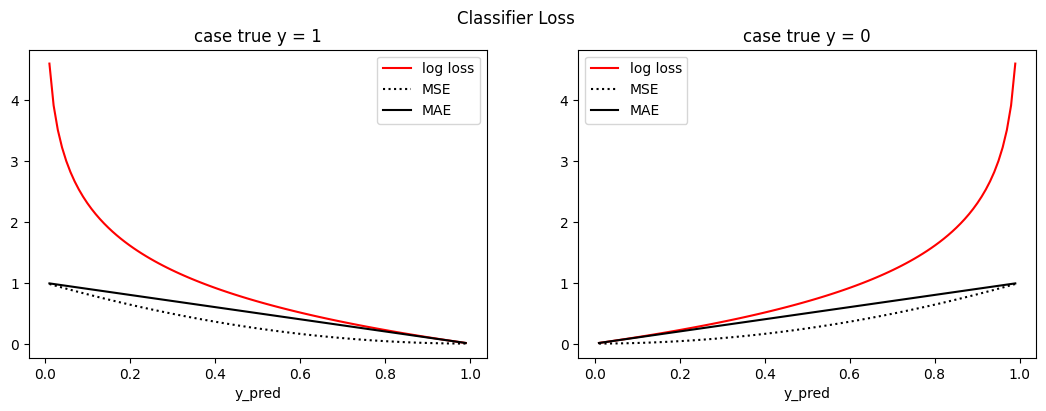

In [17]:
import matplotlib.pyplot as plt
error = np.linspace(0.01,0.99,100)
fig, axs = plt.subplots(1,2, figsize=(13,4))

# case true label = 0

axs[1].plot(error, -1*np.log(1-error), c='r', label='log loss')
axs[1].plot(error, error**2, c='black', ls=':', label='MSE')
axs[1].plot(error, np.abs(error), c='black', label='MAE')
axs[1].legend()
axs[1].set_xlabel('y_pred')
axs[1].set_title('case true y = 0')

# case true label = 1
axs[0].plot(error, -1*np.log(error), c='r', label='log loss')
axs[0].plot(error, (1 - error)**2, c='black', ls=':', label='MSE')
axs[0].plot(error, np.abs(1 - error), c='black', label='MAE')
axs[0].legend()
axs[0].set_xlabel('y_pred')
axs[0].set_title('case true y = 1')
plt.suptitle("Classifier Loss")
plt.show()

🤔 The gradient of the **log-loss** of the **sigmoid** function is simple in vectorial form 

$\nabla LogLoss_{sigmoid} = - \frac{2}{n} X^T(y - \hat{y})$  

[📚 proof](https://pdfhost.io/pdf/331cead5-4dd6-455a-9d10-17d4e12df608/8a19e1bf-c7c2-4b4d-a671-457928e79bfa.pdf)

Exact **same formula** as that of the MSE loss of a Linear Regression

$\nabla MSE_{linear} = - \frac{2}{n} X^T(y - \hat{y})$

<br>

😎 Think **vectorial** whenever possible. OLS/Logit gradient descent = ~4 lines in NumPy  

<br>

⚠️ These gradients **do not have the same value** of course as:

$\hat{y}_{sigmoid} = {\frac{1}{1+e^{- X \beta}}}\\
\hat{y}_{linear} = {X \beta}$

### Other (non-logistic) classifiers exist!

- Logistic classifier
- Support Vector Machine Classifier (SVC)
- ...

All have different losses!

# 5. Summary

**Problem setting**
- $X$ = features
- $y$ = target = $h(X, \color{blue}{\beta}) + error$
- $h$ = hypothesis function (Linear, Sigmoid, Neural Network...)

**Parameters of the model: $\color{blue}{\beta}$**
- Computed automatically during `.fit()`
- by minimizing $L(\color{blue}{\beta})$

**Hyperparameters of the model** :

_(chosen manually)_
- Loss function $L$ (MSE, MAE, Log-Loss,...)
    - Parameters of the loss itself (learning_rate, ...)
- Solver = method used to miminize $L$ ('newton', 'sdg', ...)
- Model specificities ('n_neighbors', ...)
- ...

"**Model**" is a **loosely defined** term.  

`sklearn` models generally refer to the hypothesis function $h(X, \beta)$

**Regressors**
```python
LinearRegressor() # OLS regression
KNeighborsRegressor() # KNN
SVR() # Support Vector Regressor
```

**Classifiers**
```python
LogisticRegressor() # Logit regression
KNeighborsClassifier() # KNN
SVC() # Support Vector Classifier
```

⚠️ An exception: `SGDClassifier` and `SGDRegressor` refer to a linear hypothesis function $h$, fitted using an SGD algorithm.
```python
SGDRegressor(loss='squared_loss') # eq. to OLS regression
SGDRegressor(loss='huber') # non-OLS linear regression

SGDClassifier(loss='log') # eq. to Logit
SGDClassifier(loss='hinge') # eq. to SVC
```

Finally, once a model is selected, it can be further "finetuned" by selecting **hyper-parameters** manually as model class attributes
```python
SGDRegressor(loss='squared_loss', learning_rate=0.1, eta0=0.01)
KNeighborsRegressor(n_neighbors=5)
LogisticRegression(solver='newton')
```

...and then fitted `.fit()`

## Bibliography

- 📺[StatsQuest - Gradient Descent](https://www.youtube.com/watch?v=sDv4f4s2SB8)
- 📚[Hands-On ML with SKLearn - Chapter 4](https://www.lpsm.paris/pageperso/has/source/Hand-on-ML.pdf)
- 📚[Andrew NG - Linear Models CS229 Notes](https://pdfhost.io/pdf/331cead5-4dd6-455a-9d10-17d4e12df608/8a19e1bf-c7c2-4b4d-a671-457928e79bfa.pdf)

## Your turn ! 🚀